In [16]:
import os
import httpx
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(override=True)

BASE_URL = os.getenv("OPENAI_BASE_URL")
API_KEY = os.getenv("OPENAI_API_KEY")
MODEL = os.getenv("OPENAI_MODEL")

transport = httpx.HTTPTransport(verify=False)
http_client = httpx.Client(transport=transport)

llm = ChatOpenAI(
    base_url = BASE_URL,
    api_key = API_KEY,
    model = MODEL, 
    http_client = http_client,
    streaming = False
)

In [17]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [18]:
from langgraph.types import Command, interrupt
from langchain_core.tools import tool

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

In [19]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)

In [20]:
from langgraph.prebuilt import ToolNode, tools_condition

def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    assert len(message.tool_calls) <= 1
    return {"messages": [message]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [21]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

graph = graph_builder.compile(checkpointer=memory)

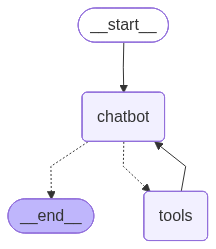

In [22]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [23]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [{"role": "user", "content": user_input}]},
     config,
     stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (01997f36e827c6a5cfa3a8d0ea1a11f2)
 Call ID: 01997f36e827c6a5cfa3a8d0ea1a11f2
  Args:
    query: I need some expert guidance for building an AI agent. Could you request assistance for me?


In [24]:
snapshot = graph.get_state(config)
snapshot.next

('tools',)

In [25]:
human_response = {
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
}

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (01997f36e827c6a5cfa3a8d0ea1a11f2)
 Call ID: 01997f36e827c6a5cfa3a8d0ea1a11f2
  Args:
    query: I need some expert guidance for building an AI agent. Could you request assistance for me?
================================= Tool Message =================================
Name: human_assistance

{"We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents."}
================================== Ai Message ==================================

The experts recommend exploring **LangGraph** (developed by Meta) for building AI agents. LangGraph is a framework designed to create structured, reliable, and extensible AI agents by organizing tasks into a graph-based workflow. It allows agents to reason through complex problems step-by-step, making it ideal for applications requiring multi-

In [26]:
snapshot = graph.get_state(config)
snapshot.next

()